In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np
from pathlib import Path

In [18]:
# Resolve the dataset path whether the notebook runs from the repo root or Assignment_2.
dataset_dir = Path("Assignment_2/ImageDataset/images")
if not dataset_dir.exists():
    dataset_dir = Path("ImageDataset/images")

image_dataset = tf.keras.utils.image_dataset_from_directory(
    str(dataset_dir),
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42,
)

class_names = image_dataset.class_names
image_batches = []
label_batches = []

# Keep images and labels from the same batch so they stay correctly matched.
for images, labels in image_dataset:
    image_batches.append(images.numpy())
    label_batches.append(labels.numpy())

x_data = np.concatenate(image_batches, axis=0)
y_data = np.concatenate(label_batches, axis=0)

train_images, test_images, train_labels, test_labels = train_test_split(
    x_data,
    y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data,
)

(x_train, y_train), (x_test, y_test) = (train_images, train_labels), (test_images, test_labels)

# MobileNetV2 expects float32 pixels scaled to the -1..1 range.
image_train = tf.keras.applications.mobilenet_v2.preprocess_input(x_train.astype("float32"))
image_test = tf.keras.applications.mobilenet_v2.preprocess_input(x_test.astype("float32"))

print(class_names)
print(image_train.shape, y_train.shape)
print(image_test.shape, y_test.shape)
print(image_train.dtype, image_train.min(), image_train.max())
print(image_test.dtype, image_test.min(), image_test.max())

Found 3000 files belonging to 3 classes.
['cats', 'dogs', 'panda']
(2400, 224, 224, 3) (2400,)
(600, 224, 224, 3) (600,)
float32 -1.0 1.0
float32 -1.0 1.0


In [22]:
num_classes = len(class_names)
input_shape = image_train.shape[1:]

# Pretrained CNN backbone - reuses image features learned from ImageNet.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=input_shape,
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

# Layer 1: Input layer - receives one MobileNetV2-preprocessed RGB image.
inputs = Input(shape=input_shape, name="input_image")

# Layer 2: MobileNetV2 feature extractor - frozen at first to prevent overfitting.
x = base_model(inputs, training=False)

# Layer 3: Global average pooling - converts feature maps into one feature vector.
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

# Layer 4: Dropout layer - helps reduce overfitting during training.
x = tf.keras.layers.Dropout(0.3, name="dropout_regularization")(x)

# Layer 5: Output layer - predicts one probability for each class.
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probabilities")(x)

model = Model(inputs=inputs, outputs=outputs, name="animal_mobilenetv2_transfer")
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "animal_mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    image_train,
    y_train,
    validation_data=(image_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 246ms/step - accuracy: 0.6229 - loss: 0.8433 - val_accuracy: 0.8917 - val_loss: 0.4638 - learning_rate: 1.0000e-04
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 219ms/step - accuracy: 0.8838 - loss: 0.4091 - val_accuracy: 0.9600 - val_loss: 0.2543 - learning_rate: 1.0000e-04
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 223ms/step - accuracy: 0.9362 - loss: 0.2582 - val_accuracy: 0.9733 - val_loss: 0.1696 - learning_rate: 1.0000e-04
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 24s 320ms/step - accuracy: 0.9604 - loss: 0.1875 - val_accuracy: 0.9750 - val_loss: 0.1287 - learning_rate: 1.0000e-04
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.9683 - loss: 0.1488 - val_accuracy: 0.9800 - val_loss: 0.1035 - learning_rate: 1.0000e-04
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 25s 341ms/step - accuracy: 0.9692 - loss: 0.1310 - val_accuracy: 0.9850 - val_loss: 0.0879 - learning_rate: 1.0000e-04
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 27s 359ms/step - acc

In [25]:
test_loss, test_accuracy = model.evaluate(image_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.0305
Test accuracy: 0.9900


In [26]:
import json

if "model" not in globals():
    raise RuntimeError("Run the model-building/training cells before saving the model.")

model_dir = Path("Assignment_2")
if not model_dir.exists():
    model_dir = Path(".")

model_path = model_dir / "animal_mobilenetv2_transfer.keras"
weights_path = model_dir / "animal_mobilenetv2_transfer.weights.h5"
labels_path = model_dir / "class_names.json"

model.save(model_path)
model.save_weights(weights_path)

with open(labels_path, "w", encoding="utf-8") as labels_file:
    json.dump(class_names, labels_file, indent=2)

print(f"Saved full model to: {model_path.resolve()}")
print(f"Saved weights to: {weights_path.resolve()}")
print(f"Saved class labels to: {labels_path.resolve()}")

Saved full model to: C:\Github\dl-ai570\Assignment_2\animal_mobilenetv2_transfer.keras
Saved weights to: C:\Github\dl-ai570\Assignment_2\animal_mobilenetv2_transfer.weights.h5
Saved class labels to: C:\Github\dl-ai570\Assignment_2\class_names.json


Loaded model test loss: 0.0305
Loaded model test accuracy: 0.9900


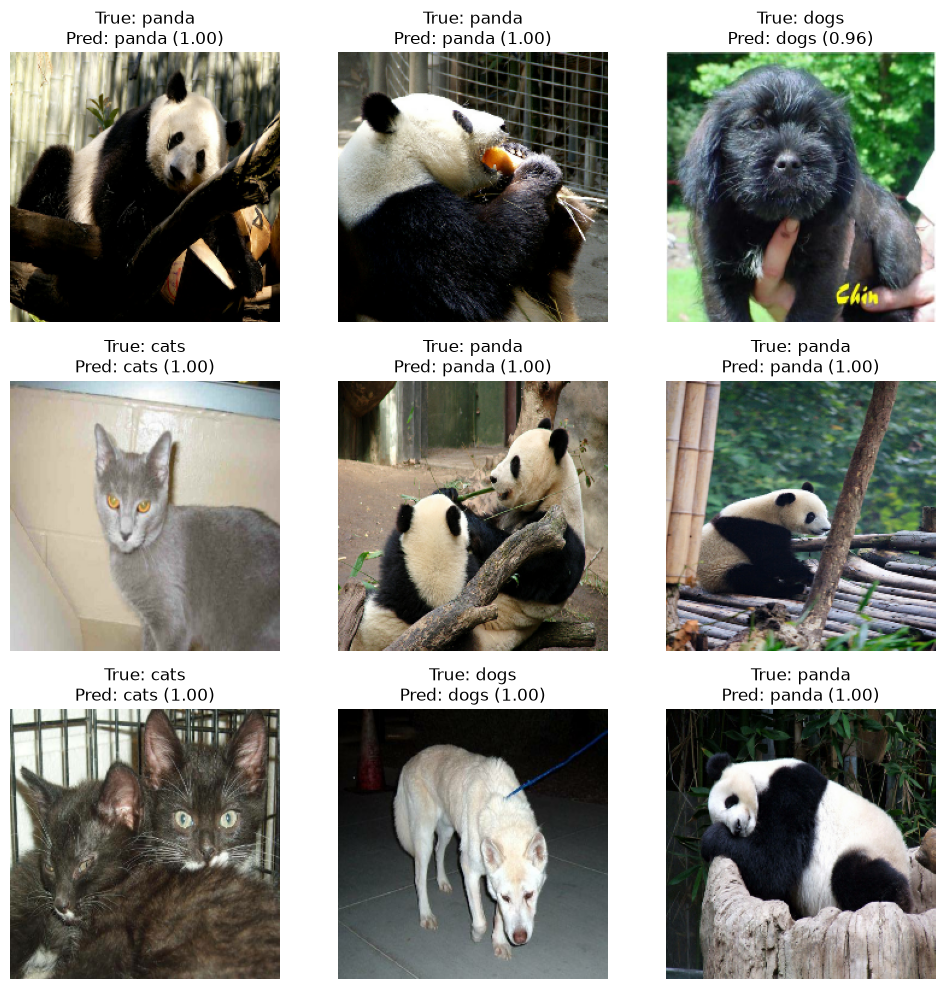

In [27]:
import matplotlib.pyplot as plt

model_dir = Path("Assignment_2")
if not model_dir.exists():
    model_dir = Path(".")

model_path = model_dir / "animal_mobilenetv2_transfer.keras"
labels_path = model_dir / "class_names.json"

loaded_model = tf.keras.models.load_model(model_path)

with open(labels_path, "r", encoding="utf-8") as labels_file:
    saved_class_names = json.load(labels_file)

loaded_loss, loaded_accuracy = loaded_model.evaluate(image_test, y_test, verbose=0)
print(f"Loaded model test loss: {loaded_loss:.4f}")
print(f"Loaded model test accuracy: {loaded_accuracy:.4f}")

sample_count = min(9, len(image_test))
sample_indices = np.arange(sample_count)
predictions = loaded_model.predict(image_test[sample_indices], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 10))
for plot_index, image_index in enumerate(sample_indices):
    true_label = saved_class_names[y_test[image_index]]
    predicted_label = saved_class_names[predicted_labels[plot_index]]
    confidence = predictions[plot_index][predicted_labels[plot_index]]

    plt.subplot(3, 3, plot_index + 1)
    plt.imshow(x_test[image_index].astype("uint8"))
    plt.title(f"True: {true_label}\nPred: {predicted_label} ({confidence:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()